In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from river.decomposition import OnlineDMDwC, OnlineSVD
from river.feature_extraction import PolynomialExtender
from river.preprocessing import Hankelizer
from tqdm import tqdm

sys.path.append("../")
from reshift.chdsubid import (
    SubIDChangeDetector,
    get_default_rank,
    get_default_timedelays,
)
from reshift.plot import plot_chd
from reshift.preprocessing import hankel
from reshift.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Read data
hm = 1
train_data = pd.read_pickle("data/nonlinear-delay-control/train_sim.pkl")  # noqa: S301  # trusted local pickle generated by this project
X = pd.DataFrame(train_data["X"][:12000])
U = pd.DataFrame(train_data["U"][:12000])

Y = np.zeros(X.shape[0])

# Introduce gaussian noise
np.random.seed(42)
X += np.random.normal(0, 0.1, X.shape)

In [ ]:
fig, axs = plt.subplots(3, 1)
axs[0].plot(X)
axs[1].plot(U)
axs[2].plot(Y)

In [ ]:
hn = 2
X_ = hankel(X, hn)[hn - 1 :]
U_ = U[hn - 1 :]
model = OnlineDMDwC(p=2)
model.learn_many(X_, U=U_)

In [ ]:
test_data = pd.read_pickle("data/nonlinear-delay-control/test_sim.pkl")  # noqa: S301  # trusted local pickle generated by this project
X_t = test_data["X"][:12000]
U_t = test_data["U"][:12000]

X_t_ = hankel(X_t, hn)[hn - 1 :]
U_t_ = U_t[hn - 1 :]

In [ ]:
Y_pred = model.predict_horizon(X_t_[0], U=U_t_, horizon=len(X_t_))[:, -2:]
fig, axs = plt.subplots(3, 1)
for i, (y, y_pred) in enumerate(zip(X_t.T, Y_pred.T, strict=False)):
    axs[i].plot(y)
    axs[i].plot(y_pred)
plt.plot(U_t_[:, -1])

In [ ]:
window_size: int = 2000
# Base size
ref_size = 200
test_size = 200
# If window_size is not very large, then take half
hm, hm_step = get_default_timedelays(200, 30 // X.shape[1])
hl, hl_step = get_default_timedelays(30, 30 // U.shape[1])
# Optimal low-rank representation of signal with unknown noise variance
p = min(X.shape[1], get_default_rank(hankel(X[:window_size], hm, hm_step)))
print(f"Optimal rank for states is: {p}")
q = min(U.shape[1], get_default_rank(hankel(U[:window_size], hl, hl_step)))
print(f"Optimal rank for inputs is: {q}")

Snapshots processed:   0%|          | 0/12000 [00:00<?, ?it/s]

Snapshots processed:  18%|█▊        | 2156/12000 [00:01<00:04, 2152.82it/s]

Snapshots processed:  18%|█▊        | 2156/12000 [00:20<00:04, 2152.82it/s]

Snapshots processed:  33%|███▎      | 4006/12000 [00:20<00:46, 170.31it/s] 

Snapshots processed:  34%|███▍      | 4104/12000 [00:21<00:49, 158.98it/s]

...

Snapshots processed:  97%|█████████▋| 11654/12000 [02:01<00:03, 92.02it/s]

Snapshots processed:  98%|█████████▊| 11748/12000 [02:02<00:02, 92.52it/s]

Snapshots processed:  99%|█████████▊| 11843/12000 [02:03<00:01, 93.03it/s]

Snapshots processed: 100%|█████████▉| 11943/12000 [02:04<00:00, 95.00it/s]

Snapshots processed: 100%|██████████| 12000/12000 [02:05<00:00, 95.97it/s]

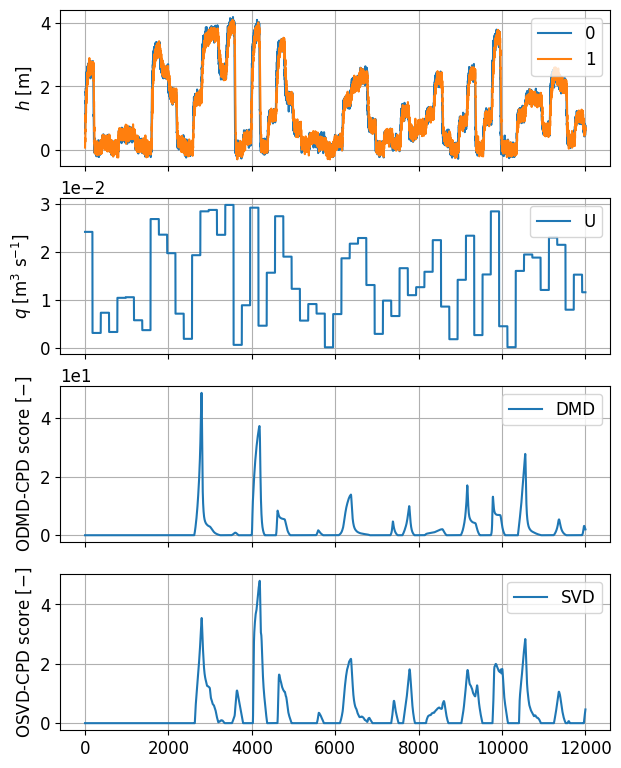

In [ ]:
# [donotremove]
# TODO(MarekWadinger): enable hankelization of us on the fly (#8)
U_ = pd.DataFrame(hankel(U, hl, hl_step))

# Initialize Hankelizer
hankelizer = Hankelizer(hm)

# Initialize Transformer
init_size = window_size
odmd = Rolling(
    OnlineDMDwC(
        p=p,
        q=q,
        initialize=init_size - 1,
        w=1.0,
        exponential_weighting=False,
        eig_rtol=None,
    ),
    init_size,
)

# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size,
    start_soon=True,
)

# Build pipeline
pipeline_dmd = PolynomialExtender(2) | hankelizer | subid_dmd


osvd = OnlineSVD(p + q, initialize=init_size, force_orth=False)
subid_svd = SubIDChangeDetector(
    osvd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)
pipeline_svd = PolynomialExtender(2) | Hankelizer(hm + hl) | subid_svd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
scores_svd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)
modes = np.empty((X.shape[0], hm * X.shape[1], p), dtype=complex)

# Run pipeline
for i, (x, u) in tqdm(
    enumerate(
        zip(
            X.to_dict(orient="records"),
            U_.to_dict(orient="records"),
            strict=False,
        ),
    ),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one(x)
    scores_svd[i] = pipeline_svd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    pipeline_dmd.learn_one(x, u=u)
    x_ = x.copy()
    x_.update({-1: u.copy().popitem()[1]})
    pipeline_svd.learn_one(x)

# Plot results
fig, axs = plot_chd(
    {
        "$h~$[m]": X,
        "$q~\\mathrm{[m^3~s^{-1}]}$": U,
        "ODMD-CPD score [$-$]": scores_dmd.real,
        "OSVD-CPD score [$-$]": scores_svd.real,
    },
    np.where(np.abs(np.diff(Y, axis=0, prepend=0)) == 1)[0],
    labels=["X", "U", "DMD", "SVD"],
    grace_period=test_size,
)
fig_name = (
    f"results/.nonlin/nonlin-chd_p{p}_q{q}-l{init_size}_b{ref_size}_t{test_size}"
    f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
    f"dmd_w{odmd.w}-hx{hm}-hl{hl}-polyext.pdf"
)
Path(fig_name).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_name)